In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('data.csv', encoding = 'latin1')

In [10]:
df.shape


(541909, 8)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [13]:
cancelled_orders = df[df['InvoiceNo'].astype(str).str.startswith('C') | (df['Quantity'] < 0)].copy()
print(cancelled_orders)

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

            InvoiceDate  UnitPrice  CustomerID         Country  
141      12/1/2010 9:41      27.50     14527.0

In [14]:
df_clean = df.dropna(subset = ['CustomerID'])

In [15]:
df_clean = df.dropna(subset=['CustomerID']).copy()

df_clean = df_clean[df_clean['Quantity'] > 0].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [16]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [18]:
customer_agg = df_clean.groupby('CustomerID').agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('InvoiceNo', 'nunique'),
    avg_order_value=('Revenue', 'mean')
).reset_index()
print(customer_agg)

      CustomerID  total_revenue  total_orders  avg_order_value
0          12346           0.00             2         0.000000
1          12347        4310.00             7        23.681319
2          12348        1797.24             4        57.975484
3          12349        1757.55             1        24.076027
4          12350         334.40             1        19.670588
...          ...            ...           ...              ...
4367       18280         180.60             1        18.060000
4368       18281          80.82             1        11.545714
4369       18282         176.60             3        13.584615
4370       18283        2094.88            16         2.771005
4371       18287        1837.28             3        26.246857

[4372 rows x 4 columns]


In [19]:
country_agg = df_clean.groupby('Country').agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('InvoiceNo', 'nunique')
).reset_index()
print(country_agg)

                 Country  total_revenue  total_orders
0              Australia     137077.270            69
1                Austria      10154.320            19
2                Bahrain        548.400             2
3                Belgium      40910.960           119
4                 Brazil       1143.600             1
5                 Canada       3666.380             6
6        Channel Islands      20086.290            33
7                 Cyprus      12946.290            20
8         Czech Republic        707.720             5
9                Denmark      18768.140            21
10                  EIRE     250285.220           319
11    European Community       1291.750             5
12               Finland      22326.740            48
13                France     196712.840           458
14               Germany     221698.210           603
15                Greece       4710.520             6
16               Iceland       4310.000             7
17                Israel    

In [28]:
total_global_revenue = country_agg['total_revenue'].sum()
print(f"total_global_revenue: {total_global_revenue}")


total_global_revenue: 8300065.813999998


In [33]:
country_agg['revenue_share_%'] = (country_agg['total_revenue'] / total_global_revenue) * 100
print(country_agg['revenue_share_%'])


35    81.539997
23     3.429630
10     3.015461
14     2.671042
13     2.370015
0      1.651520
32     0.671554
30     0.659929
3      0.492899
31     0.440911
19     0.425787
24     0.423653
26     0.350115
12     0.268995
6      0.242002
9      0.226120
18     0.203499
7      0.155978
1      0.122340
29     0.109883
25     0.086905
17     0.084267
15     0.056753
16     0.051927
5      0.044173
36     0.032133
22     0.030186
34     0.022919
33     0.020854
20     0.020408
21     0.020013
11     0.015563
4      0.013778
27     0.012076
8      0.008527
2      0.006607
28     0.001580
Name: revenue_share_%, dtype: float64


In [34]:
country_agg = country_agg.sort_values(by='total_revenue', ascending=False)
print(country_agg)

                 Country  total_revenue  total_orders  revenue_share_%
35        United Kingdom    6767873.394         19857        81.539997
23           Netherlands     284661.540           101         3.429630
10                  EIRE     250285.220           319         3.015461
14               Germany     221698.210           603         2.671042
13                France     196712.840           458         2.370015
0              Australia     137077.270            69         1.651520
32           Switzerland      55739.400            71         0.671554
30                 Spain      54774.580           105         0.659929
3                Belgium      40910.960           119         0.492899
31                Sweden      36595.910            46         0.440911
19                 Japan      35340.620            28         0.425787
24                Norway      35163.460            40         0.423653
26              Portugal      29059.810            70         0.350115
12    

In [36]:
total_orders_per_country = df.groupby('Country')['InvoiceNo'].nunique()
print(total_orders_per_country)

Country
Australia                  69
Austria                    19
Bahrain                     4
Belgium                   119
Brazil                      1
Canada                      6
Channel Islands            33
Cyprus                     20
Czech Republic              5
Denmark                    21
EIRE                      360
European Community          5
Finland                    48
France                    461
Germany                   603
Greece                      6
Hong Kong                  15
Iceland                     7
Israel                      9
Italy                      55
Japan                      28
Lebanon                     1
Lithuania                   4
Malta                      10
Netherlands               101
Norway                     40
Poland                     24
Portugal                   71
RSA                         1
Saudi Arabia                2
Singapore                  10
Spain                     105
Sweden                     46
Sw

In [37]:
cancelled_orders_per_country = cancelled_orders.groupby('Country')['InvoiceNo'].nunique()
print(cancelled_orders_per_country)

Country
Australia               12
Austria                  2
Bahrain                  1
Belgium                 21
Channel Islands          7
Cyprus                   4
Czech Republic           3
Denmark                  3
EIRE                    72
European Community       1
Finland                  7
France                  69
Germany                146
Greece                   1
Hong Kong                4
Israel                   1
Italy                   17
Japan                    9
Malta                    5
Netherlands              6
Norway                   4
Poland                   5
Portugal                13
Saudi Arabia             1
Singapore                3
Spain                   15
Sweden                  10
Switzerland             20
USA                      2
United Kingdom        4708
Name: InvoiceNo, dtype: int64


In [40]:
# return rate percentage per country
total_orders_per_country = df.groupby('Country')['InvoiceNo'].nunique()
cancelled_orders_per_country = cancelled_orders.groupby('Country')['InvoiceNo'].nunique()

return_rate_df = pd.DataFrame({
    'total_orders': total_orders_per_country,
    'cancelled_orders': cancelled_orders_per_country
}).fillna(0)

return_rate_df['return_rate_%'] = (return_rate_df['cancelled_orders'] / return_rate_df['total_orders']) * 100

return_rate_df = return_rate_df.sort_values(by='return_rate_%', ascending=False)

print("Top 10 Countries by Return Rate:")
print(return_rate_df.head(10))

Top 10 Countries by Return Rate:
                total_orders  cancelled_orders  return_rate_%
Country                                                      
Czech Republic             5               3.0      60.000000
Malta                     10               5.0      50.000000
Saudi Arabia               2               1.0      50.000000
Japan                     28               9.0      32.142857
Italy                     55              17.0      30.909091
Singapore                 10               3.0      30.000000
USA                        7               2.0      28.571429
Switzerland               74              20.0      27.027027
Hong Kong                 15               4.0      26.666667
Bahrain                    4               1.0      25.000000


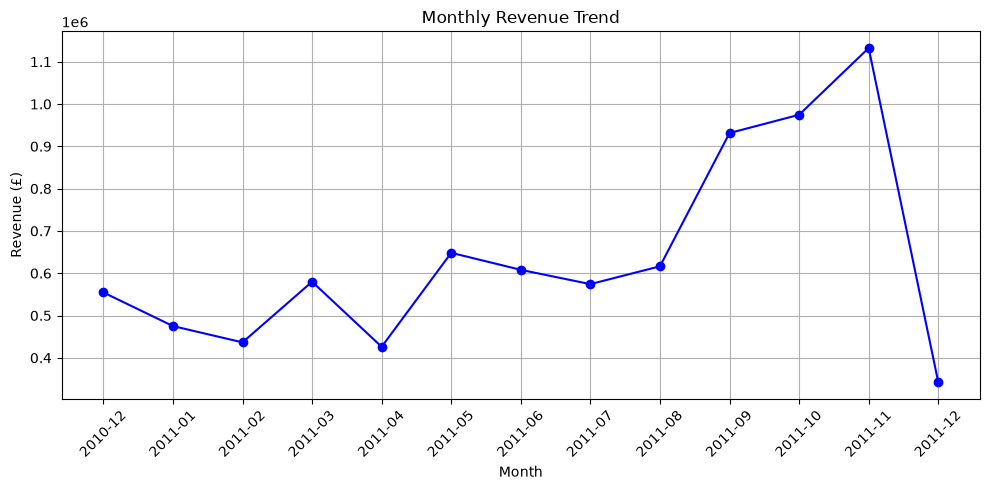

In [42]:
# monthly revenue 

monthly_rev = df_clean.groupby(df_clean['InvoiceDate'].dt.strftime('%Y-%m'))['Revenue'].sum()

plt.figure(figsize=(10, 5))

plt.plot(monthly_rev.index, monthly_rev.values, marker='o', color='blue', linestyle='-')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

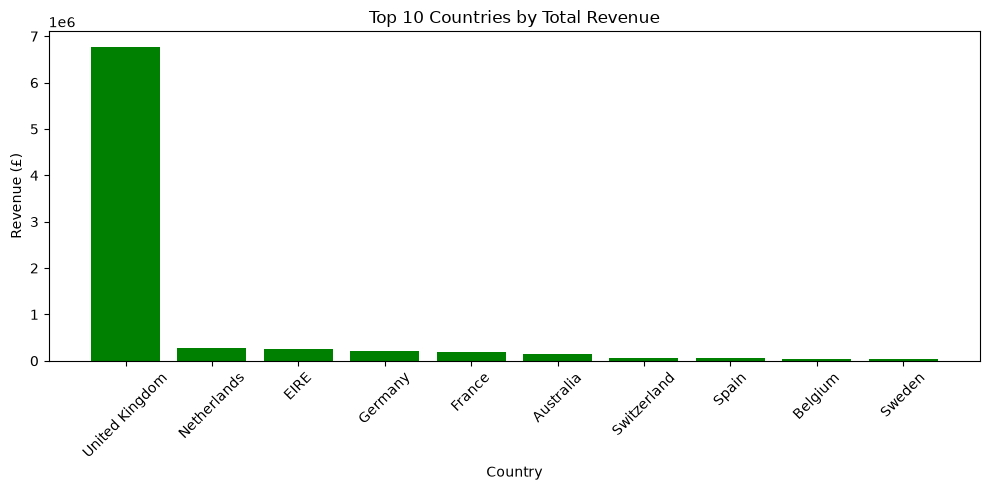

In [43]:
# Top 10 countries for high total revenue

top_10_countries = country_agg.head(10)

countries = top_10_countries['Country']
country_revenues = top_10_countries['total_revenue']

plt.figure(figsize=(10, 5))

plt.bar(countries, country_revenues, color='green')

plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

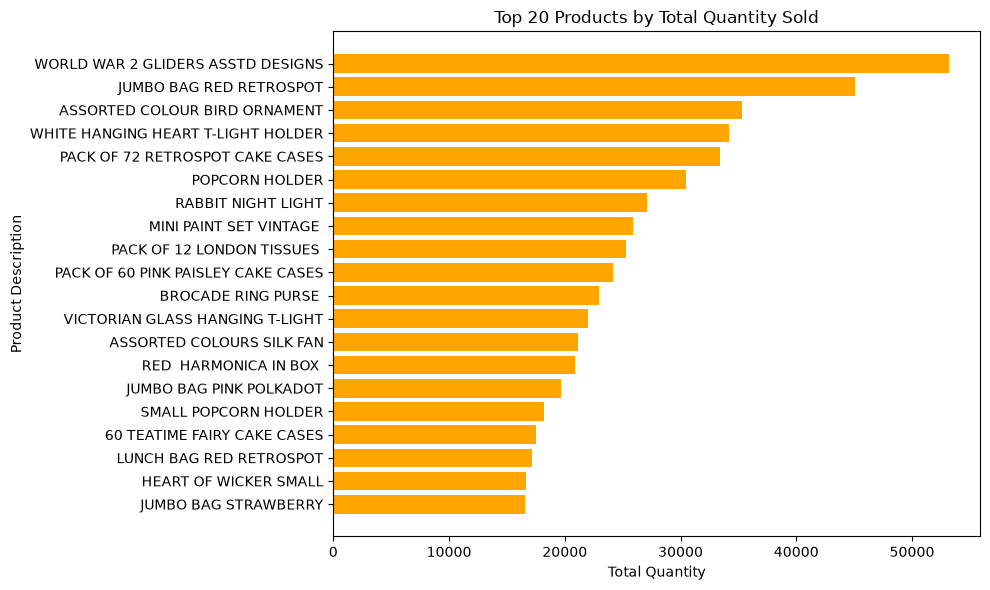

In [44]:
# Top 20 products by quantity sold

top_20_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

top_20_sorted = top_20_products.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(top_20_sorted.index, top_20_sorted.values, color='orange')

plt.title('Top 20 Products by Total Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Product Description')

plt.tight_layout()
plt.show()

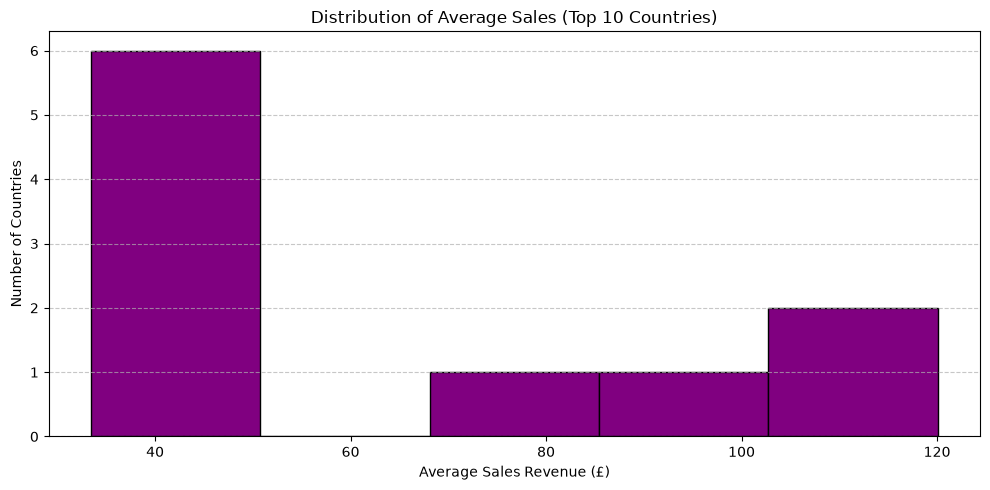

In [45]:
# Top 10 countries by average sales

top10_avg_sales = df_clean.groupby('Country')['Revenue'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.hist(top10_avg_sales.values, bins=5, color='purple', edgecolor='black')

plt.title('Distribution of Average Sales (Top 10 Countries)')
plt.xlabel('Average Sales Revenue (£)')
plt.ylabel('Number of Countries')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()